In [17]:
!pip install -U transformers accelerate scikit-learn seaborn

In [18]:
import pandas as pd
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

import torch.nn as nn

In [19]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [20]:
df = pd.read_csv('/content/Review_balanced.csv')

df = df[['reviewText', 'overall']]
df.dropna(inplace=True)

In [21]:
def sentiment_label(rating):
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

df['label'] = df['overall'].apply(sentiment_label)

df = df[['reviewText', 'label']]

print(df['label'].value_counts())

label
2    538
0    521
1    390
Name: count, dtype: int64


In [22]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['reviewText'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

In [23]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=200
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=200
)

In [24]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [25]:
train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)

In [26]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [27]:
for param in model.distilbert.transformer.layer[:3].parameters():
    param.requires_grad = False

In [28]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)

tensor([0.9265, 1.2382, 0.8984])


In [29]:
class WeightedTrainer(Trainer):

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [30]:
training_args = TrainingArguments(

    output_dir="./results",

    learning_rate=1.5e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=10,

    weight_decay=0.01,

    warmup_steps=300,

    max_grad_norm=1.0,

    logging_dir="./logs",

    seed=42
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [31]:
trainer = WeightedTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [32]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.871288
1000,0.374494


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1450, training_loss=0.48869286372743803, metrics={'train_runtime': 10917.6978, 'train_samples_per_second': 1.062, 'train_steps_per_second': 0.133, 'total_flos': 599736144636000.0, 'train_loss': 0.48869286372743803, 'epoch': 10.0})

In [33]:
predictions = trainer.predict(val_dataset)

preds = np.argmax(predictions.predictions, axis=1)

print("Accuracy:", accuracy_score(val_labels, preds))
print(classification_report(val_labels, preds))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.7379310344827587
              precision    recall  f1-score   support

           0       0.78      0.74      0.76       104
           1       0.57      0.64      0.60        78
           2       0.84      0.81      0.82       108

    accuracy                           0.74       290
   macro avg       0.73      0.73      0.73       290
weighted avg       0.75      0.74      0.74       290



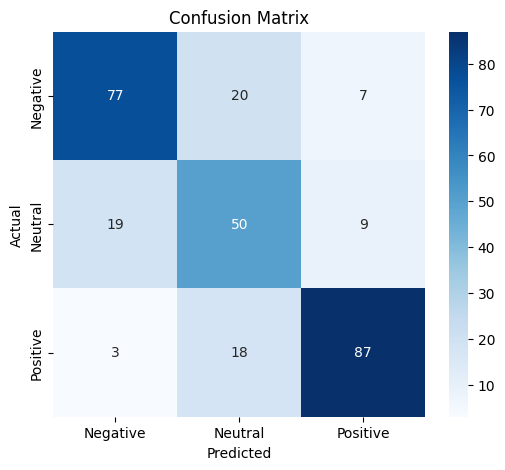

In [34]:
cm = confusion_matrix(val_labels, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Neutral','Positive'],
    yticklabels=['Negative','Neutral','Positive']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

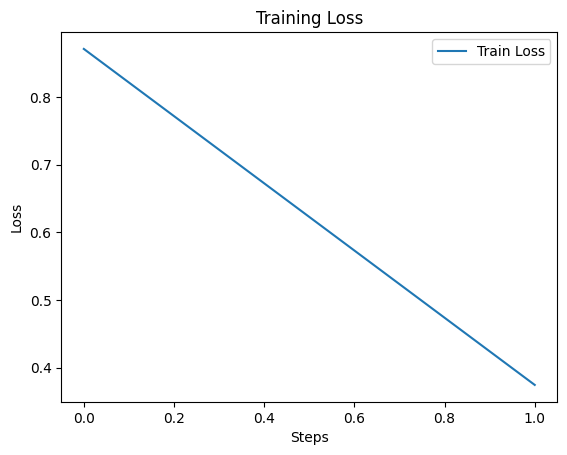

In [35]:
logs = trainer.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]

plt.plot(train_loss, label="Train Loss")

plt.legend()
plt.title("Training Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")

plt.show()